# Round 3 — Options Analysis

Analysis of the 10 VEV vouchers and their underlying `VELVETFRUIT_EXTRACT`.

See `DESIGN.md` for the notebook outline.

## A. Setup & load

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import helpers

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "Data"))
OUTPUT_DIR = os.path.abspath(os.path.join(os.getcwd(), "output"))
os.makedirs(OUTPUT_DIR, exist_ok=True)

PRICE_FILES = [
    "prices_round_3_day_0.csv",
    "prices_round_3_day_1.csv",
    "prices_round_3_day_2.csv",
]
TRADE_FILES = [
    "trades_round_3_day_0.csv",
    "trades_round_3_day_1.csv",
    "trades_round_3_day_2.csv",
]

STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VOUCHERS = [f"VEV_{K}" for K in STRIKES]
UNDERLYING = "VELVETFRUIT_EXTRACT"

IV_DOWNSAMPLE = 10  # compute IV on every Nth row

In [3]:
prices_all = helpers.load_prices(DATA_DIR, PRICE_FILES)

# Underlying path + voucher rows
u = prices_all[prices_all["product"] == UNDERLYING].copy()
v = prices_all[prices_all["product"].isin(VOUCHERS)].copy()

# Attach strike integer + TTE years
v["strike"] = v["product"].str.replace("VEV_", "", regex=False).astype(int)
v["tte_years"] = [helpers.tte_years(int(d), int(t))
                  for d, t in zip(v["day"], v["timestamp"])]

# Attach underlying mid on (day, timestamp) — prices are tick-aligned
u_key = u[["day", "timestamp", "mid_price"]].rename(columns={"mid_price": "underlying_mid"})
v = v.merge(u_key, on=["day", "timestamp"], how="left")
v["moneyness"] = v["underlying_mid"] / v["strike"]

print(f"underlying rows: {len(u):>7,}")
print(f"voucher rows   : {len(v):>7,}")

underlying rows:  30,000
voucher rows   : 300,000


### A.5 Data quality summary

In [4]:
qc = (v.groupby(["strike", "day"])
        .agg(rows=("timestamp", "size"),
             nan_mid=("mid_price", lambda s: s.isna().sum()),
             zero_mid=("mid_price", lambda s: (s == 0).sum()),
             mean_quoted_size=("bid_volume_1", lambda s: s.fillna(0).mean()))
        .reset_index())
display(qc)

,strike,day,rows,nan_mid,zero_mid,mean_quoted_size
0,4000,0,10000,0,0,10.907000
1,4000,1,10000,0,0,10.948200
2,4000,2,10000,0,0,10.909400
3,4500,0,10000,0,0,8.920400
4,4500,1,10000,0,0,8.920900
5,4500,2,10000,0,0,9.011800
6,5000,0,10000,0,0,15.233600
7,5000,1,10000,0,0,15.316900
8,5000,2,10000,0,0,15.427800
9,5100,0,10000,0,0,19.096800


## B. Price behaviour

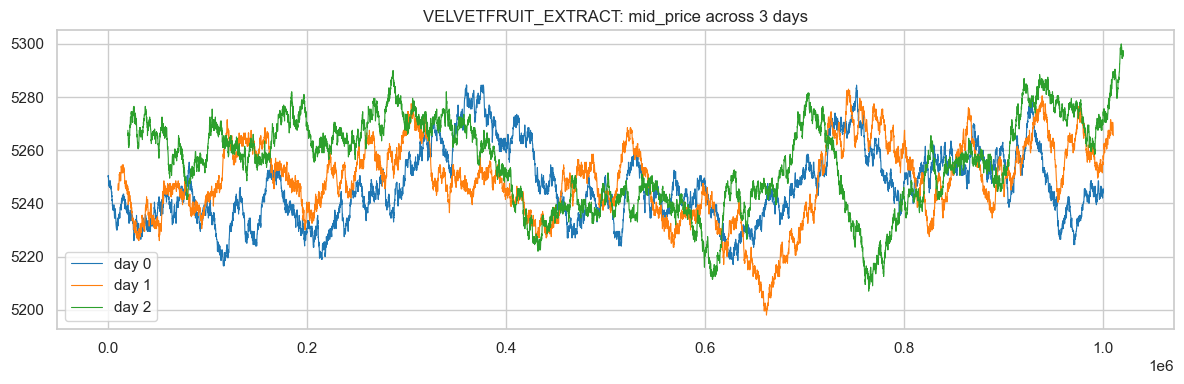

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
for d, color in zip(sorted(u["day"].unique()), sns.color_palette("tab10")):
    s = u[u["day"] == d].sort_values("timestamp")
    ax.plot(s["timestamp"].to_numpy() + d * helpers.TIMESTAMPS_PER_DAY,
            s["mid_price"].to_numpy(), label=f"day {d}", color=color, lw=0.8)
ax.set_title(f"{UNDERLYING}: mid_price across 3 days")
ax.legend()
plt.tight_layout()
plt.show()

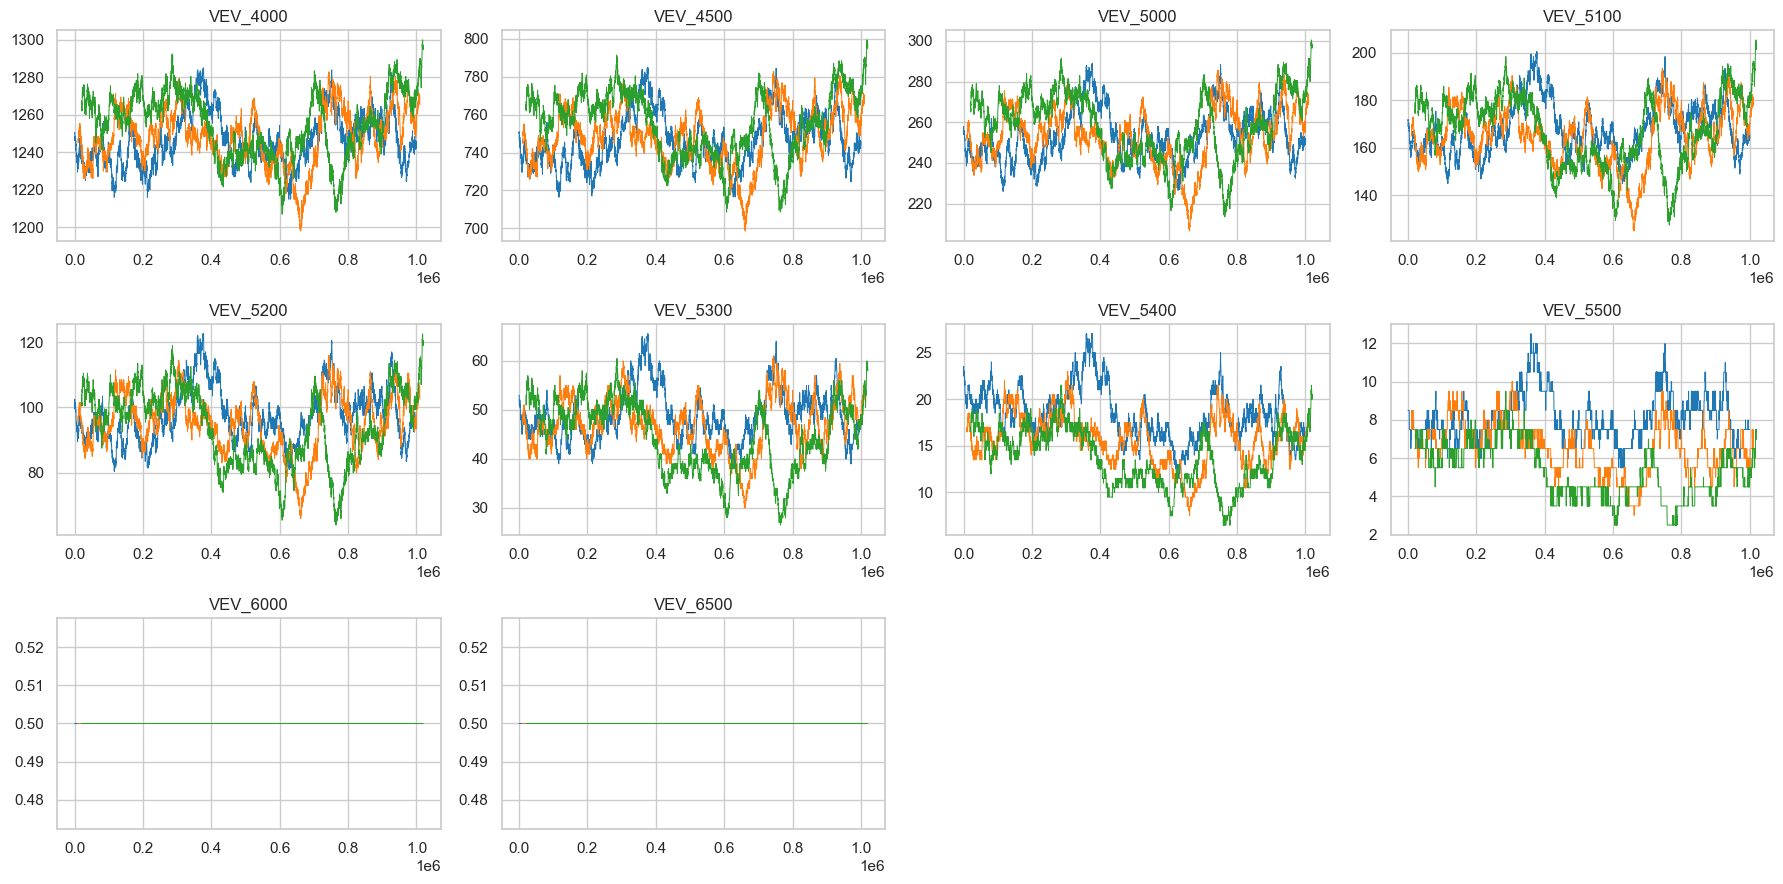

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(18, 9), sharex=False)
for ax, K in zip(axes.ravel(), STRIKES):
    s_v = v[v["strike"] == K].sort_values(["day", "timestamp"])
    for d, color in zip(sorted(s_v["day"].unique()), sns.color_palette("tab10")):
        sd = s_v[s_v["day"] == d]
        ax.plot(sd["timestamp"].to_numpy() + d * helpers.TIMESTAMPS_PER_DAY,
                sd["mid_price"].to_numpy(), color=color, lw=0.7, label=f"d{d}")
    ax.set_title(f"VEV_{K}")
# turn off unused axes
for ax in axes.ravel()[len(STRIKES):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
per_strike = (v.groupby("strike")
                .agg(rows=("timestamp", "size"),
                     mean_mid=("mid_price", "mean"),
                     mean_spread=("mid_price", lambda s: (s.std() if len(s) else np.nan)),
                     mean_quoted_size_bid=("bid_volume_1", lambda s: s.fillna(0).mean()),
                     mean_quoted_size_ask=("ask_volume_1", lambda s: s.fillna(0).mean()))
                .reset_index())
# Recompute mean_spread more precisely as ask_price_1 - bid_price_1
spread = (v.assign(spread=v["ask_price_1"] - v["bid_price_1"])
            .groupby("strike")["spread"].mean().rename("mean_spread"))
per_strike = per_strike.drop(columns="mean_spread").merge(spread, on="strike")
display(per_strike)

,strike,rows,mean_mid,mean_quoted_size_bid,mean_quoted_size_ask,mean_spread
0,4000,30000,1250.109800,10.921533,10.919900,20.813467
1,4500,30000,750.109567,8.951033,8.948767,15.852667
2,5000,30000,255.022400,15.326100,15.484267,6.043333
3,5100,30000,166.805450,19.248367,19.347933,4.295833
4,5200,30000,95.548767,22.563433,22.508733,2.888133
5,5300,30000,46.759933,20.283800,20.242867,2.106800
6,5400,30000,15.951917,21.763033,21.719133,1.381433
7,5500,30000,6.641350,22.178067,22.171667,1.149767
8,6000,30000,0.500000,22.476167,22.478867,1.000000
9,6500,30000,0.500000,15.479433,15.482133,1.000000
